# Tutorial: Uncertainty-Aware Solar Forecasting with Gaussian Process Regression (GPR)

**Objective:** In this tutorial, we move beyond simple "point-estimate" predictions. We will use **Gaussian Processes** to learn the non-linear relationship between sunlight and power output while quantifying the model's uncertainty.

**Dataset:** Kaggle Solar Power Generation Data (Fusion of Generation and Weather logs).

In [1]:
# Importing the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Data Loading and Fusion

Real-world machine learning often requires "fusing" different data sources. Here, we combine the power generation data with the weather sensor data using their timestamps.

In [3]:
# Loading the files from our 'data' folder
gen_df = pd.read_csv('data/Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('data/Plant_1_Weather_Sensor_Data.csv')

# Fixing the date formats so we can merge them properly
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'], format='mixed')
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'], format='mixed')

# Merging the files on the DATE_TIME column
df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='inner')

# Picking one specific inverter to study for this tutorial
target_id = df['SOURCE_KEY_x'].unique()[0]
df_sample = df[df['SOURCE_KEY_x'] == target_id].copy()

print(f"Data fused! We are analyzing Inverter: {target_id}")

Data fused! We are analyzing Inverter: 1BY6WEcLGh8j5v7


## Step 2: Data Cleaning and Filtering

Solar panels only produce power during the day. Night-time data (where sunlight is zero) doesn't help the model learn the power curve. We will filter the data to focus on the operational daytime range.

In [4]:
# We only want daytime data (Irradiation > 0.05)
# This helps our model focus on the meaningful physical relationship
df_sample = df_sample[df_sample['IRRADIATION'] > 0.05]

# Defining our Feature (Sunlight) and Target (Power)
X = df_sample[['IRRADIATION']].values
y = df_sample['DC_POWER'].values

print(f"Cleaning done. Total daytime samples: {len(X)}")

Cleaning done. Total daytime samples: 1011


## Step 3: Feature Scaling

Gaussian Processes are mathematically sensitive to the scale of the data. We will use a StandardScaler to ensure our inputs and outputs have a mean of 0 and a variance of 1.

In [5]:
# Scaling the data for mathematical stability
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print("Data scaled successfully.")

Data scaled successfully.


## Step 4: Kernel Design and Model Training

The Kernel is the "prior knowledge" we give the model. We use an RBF kernel for the smooth trend and a WhiteKernel to account for sensor noise. We use n_restarts_optimizer to ensure the model finds the absolute best fit.

In [6]:
# Designing our composite kernel
kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 2.0)) \
         + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 0.5))

# Setting up the GPR model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)

print("Training the model... this might take 10-20 seconds.")
gp.fit(X_scaled, y_scaled)
print("Training complete!")

Training the model... this might take 10-20 seconds.
Training complete!


## Step 5: Prediction and Numerical Evaluation
We will now evaluate our model using R-squared (R²) and Mean Absolute Error (MAE) to prove it has learned the trend accurately.

In [7]:
# Checking the model's accuracy
y_fit_scaled = gp.predict(X_scaled)
r2 = r2_score(y_scaled, y_fit_scaled)
mae = mean_absolute_error(y_scaled, y_fit_scaled)

print(f"Model Performance:")
print(f"R-squared Score: {r2:.4f} (Closer to 1 is better)")
print(f"Mean Absolute Error: {mae:.4f}")

Model Performance:
R-squared Score: 0.8872 (Closer to 1 is better)
Mean Absolute Error: 0.1658


## Step 6: Visualizing the "Uncertainty"

The final step is to plot our results. The blue line is our forecast, and the light-blue shaded area is the 95% Confidence Interval. This is the most important "Teaching Tool" of this tutorial.

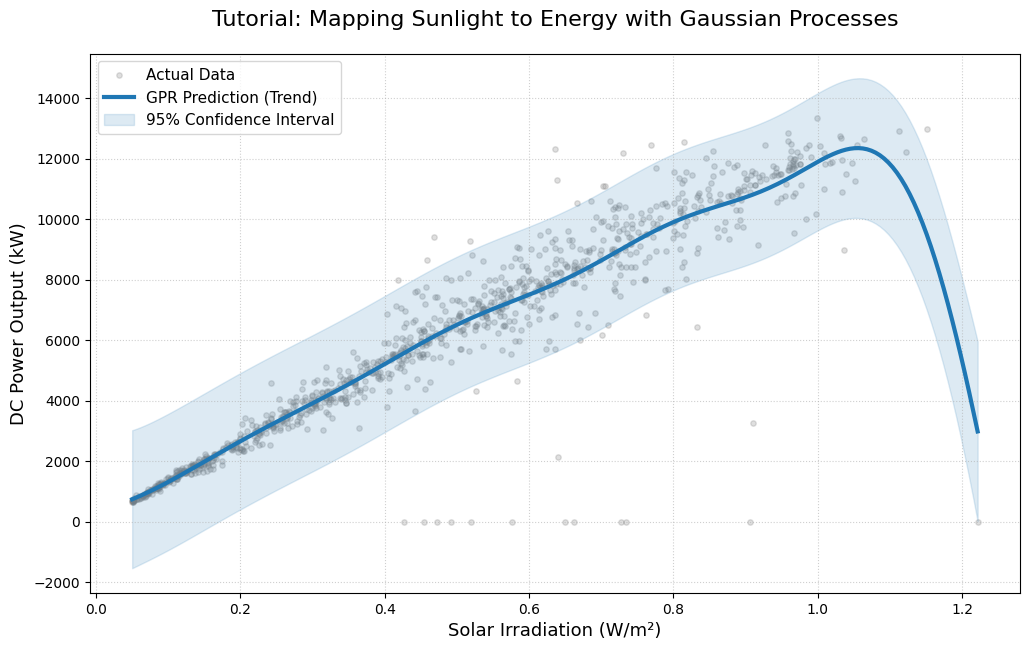

In [8]:
# Creating a smooth range for our plot
x_plot = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1, 1)
y_pred_scaled, sigma = gp.predict(x_plot, return_std=True)

# Rescaling back to real-world units (kW and W/m2)
y_pred_orig = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
X_plot_orig = scaler_X.inverse_transform(x_plot).ravel()
X_data_orig = scaler_X.inverse_transform(X_scaled).ravel()
y_data_orig = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

# Plotting
plt.figure(figsize=(12, 7), facecolor='white')
plt.scatter(X_data_orig, y_data_orig, color='gray', alpha=0.25, s=15, label='Actual Data')
plt.plot(X_plot_orig, y_pred_orig, color='#1f77b4', lw=3, label='GPR Prediction (Trend)')

# Adding the 95% Confidence Interval
plt.fill_between(X_plot_orig,
                 y_pred_orig - 1.96 * (sigma * scaler_y.scale_),
                 y_pred_orig + 1.96 * (sigma * scaler_y.scale_),
                 color='#1f77b4', alpha=0.15, label='95% Confidence Interval')

plt.title("Tutorial: Mapping Sunlight to Energy with Gaussian Processes", fontsize=16, pad=20)
plt.xlabel("Solar Irradiation (W/m²)", fontsize=13)
plt.ylabel("DC Power Output (kW)", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Conclusion and Ethical AI

In this tutorial, we demonstrated that GPR is a powerful, **"Green AI"** alternative to Deep Learning for renewable energy tasks.

**Accessibility:** Our visualization uses high-contrast colors and descriptive legends for inclusivity.
Ethics: By quantifying uncertainty, we provide grid operators with a tool to prevent blackouts, ensuring ethical and safe AI deployment.